### Imports

In [1]:
import json
import os
import pandas as pd

from utils_MS import *

# %load_ext autotime

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/outdated/utils.py:14: OutdatedPackageWarning: The package pingouin is out of date. Your version is 0.5.3, the latest is 0.6.1.
Set the environment variable OUTDATED_IGNORE=1 to disable these warnings.
  return warn(


In [2]:
# def run(params):

### Parameters

In [3]:
""" try:
    dir = os.path.dirname(os.path.abspath(__file__))
except:
    dir = os.getcwd()
print(dir) """

' try:\n    dir = os.path.dirname(os.path.abspath(__file__))\nexcept:\n    dir = os.getcwd()\nprint(dir) '

In [4]:
dict_dataset = {
    1: ["Mentos_2_process_NormalizationFiltered_format", ["Orange"]], # new mentos,  for Metabolomics
    2: ["deybis_filter_september_2br_3ar_format", ["SecoAmazonas"]],
    3: ["deybis_filter_december_2br_3ar_format", ["SecoAmazonas"]],
    4: ["deybis_filter_september_2br_10ar_format", ["SecoAmazonas"]],
    5: ["deybis_filter_december_2br_10ar_format", ["SecoAmazonas"]], # for Metabolomics
    6: ["deybis_filter_september_min_2br_3ar_format", ["SecoAmazonas"]],
    7: ["deybis_filter_december_min_2br_3ar_format", ["SecoAmazonas"]],
    8: ["vanessa_december_2br_3ar_format", ["SecoAmazonas"]],
    9: ["Pablo_2br_nar_format", ["AR"]],
    10: ["Pablo_2br_14ar_format", ["AR"]],
}
dataset = dict_dataset[9] # change
dataset

['Pablo_2br_nar_format', ['AR']]

In [5]:
params = {
    "exp": "exp0", # Change
    "methods": ["t-gae"], # ["vgae-base", "argva-base", "vgae-line", "dgi-tran", "t-gae"],
    "data_variations": ["none"],
    "has_transformation": True, # True or False
    "controls": dataset[1],
    "dimension": 64,
    "threshold_corr": 0.5,
    "threshold_log2": 0,
    "alpha": 0.05,
    "iterations": 1,
    "raw_data_file": dataset[0],
    "groups_id_no": ["Blank", "QC", "Std"],
    "sensitivity": False, # False: f1 (selectivity), True: f1 (selectivity), f2 (sensitivity)
    "obs": "",
    "seeds": [41, 42, 43, 44, 45, 46],
    
    "from": "python",
    "cuda": 0,
    "epochs": 100,
    "lr": 0.0001,
    "weight_decay": 1e-4,
    "patience": 10,
    "contamination": 0.1, # float in (0., 0.5)
    "n_jobs": 1, # -1 all
}

In [6]:
""" dir_path = "experiments/output"
res = sorted(os.listdir(dir_path))
n = len(res)
exp = "exp{}".format(n) """

exp = str(params["exp"])
exp

'exp0'

### Load dataset

In [7]:
# load dataset groups
if params["from"] == "python":
    df_raw = pd.read_csv("experiments/raw_data/{}.csv".format(params["raw_data_file"]), delimiter="|")
elif params["from"] == "drf":
    df_raw = pd.read_csv("{}".format(params["raw_data_file"]), delimiter="|") # from DRF
df_raw

,Alignment ID,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


### Format dataset

In [8]:
# has transformation
""" columns_data = list(df_raw.columns)[4:]
if params["has_transformation"]:
    print("transformation")
    for column in columns_data:
        df_raw[column] = df_raw[column].apply(lambda x: 10**x)
df_raw """

' columns_data = list(df_raw.columns)[4:]\nif params["has_transformation"]:\n    print("transformation")\n    for column in columns_data:\n        df_raw[column] = df_raw[column].apply(lambda x: 10**x)\ndf_raw '

In [9]:
# concat
df_join_raw = pd.concat([
    df_raw.iloc[:, :]], axis=1)
df_join_raw.set_index("Alignment ID", inplace=True)
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
Alignment ID,,,,,,,,,,,,,,,,,,,,,
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369


In [10]:
# split
df_join_raw = df_join_raw.rename_axis(None)
# df_join_raw = df_join_raw.iloc[:, 2:]
df_join_raw

,Average Rt,Average Mz,Metabolite name,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,1.0,69.99951,Unknown,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,1.0,70.04025,Unknown,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,1.0,70.04151,Unknown,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,1.0,70.04908,Unknown,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.0,70.06267,Unknown,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,1.0,732.79951,Unknown,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,1.0,748.76437,Unknown,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.0,794.79590,Unknown,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.0,800.81295,Unknown,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


## Preprocessing

In [11]:
# get metadata
df_join_raw_metadata = df_join_raw.iloc[:, :2]
df_join_raw_metadata

,Average Rt,Average Mz
0,1.0,69.99951
1,1.0,70.04025
2,1.0,70.04151
3,1.0,70.04908
4,1.0,70.06267
...,...,...
5439,1.0,732.79951
5440,1.0,748.76437
5441,1.0,794.79590
5442,1.0,800.81295


In [12]:
df_join_raw_intensity = df_join_raw.iloc[:, 3:]
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,0.001144,0.120999,0.212084,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,-0.226744,0.036429,0.186288,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,0.080823,0.361589,0.471603,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,0.328276,0.626443,0.796229,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [13]:
# get groups name
groups_id = []
for item in df_join_raw_intensity.columns.values:
    group_id = item.split("_")[0]
    groups_id.append(group_id)
groups_id

['AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',

Option 1

In [18]:
# Partial correlation

""" df_matrix = pg.pcorr(df_join_raw_intensity)
df_matrix """


from sklearn.preprocessing import StandardScaler
from sklearn.covariance import LedoitWolf
scaler = StandardScaler()

df_subgroup_scaled = scaler.fit_transform(df_join_raw_intensity)
lw = LedoitWolf()
lw.fit(df_subgroup_scaled)

# Matriz de covarianza regularizada
cov = lw.covariance_
std = np.sqrt(np.diag(cov))
corr = cov / np.outer(std, std)
df_matrix = pd.DataFrame(corr)
df_matrix

,0,1,2,3,4,5,6,7,8,9,...,1238,1239,1240,1241,1242,1243,1244,1245,1246,1247
0,1.000000,0.803174,0.770520,0.768016,0.754797,0.771109,0.776734,0.791224,0.794151,0.748000,...,0.812867,0.712312,0.794851,0.716688,0.806358,0.815801,0.758446,0.733050,0.826229,0.808723
1,0.803174,1.000000,0.865088,0.876837,0.879661,0.844046,0.865015,0.854433,0.858239,0.788254,...,0.788800,0.793079,0.783032,0.788629,0.791292,0.798131,0.772492,0.803614,0.793588,0.811150
2,0.770520,0.865088,1.000000,0.869977,0.848526,0.834167,0.856619,0.856061,0.842869,0.767407,...,0.787912,0.771909,0.750284,0.764355,0.775948,0.790659,0.763204,0.766518,0.784452,0.785591
3,0.768016,0.876837,0.869977,1.000000,0.888799,0.839262,0.868481,0.854048,0.852202,0.768426,...,0.773363,0.786321,0.762148,0.776969,0.770177,0.781799,0.761029,0.793693,0.766869,0.788800
4,0.754797,0.879661,0.848526,0.888799,1.000000,0.828061,0.863052,0.835452,0.840942,0.761618,...,0.749999,0.773889,0.749644,0.762683,0.747192,0.756134,0.737757,0.782320,0.753619,0.778120
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1243,0.815801,0.798131,0.790659,0.781799,0.756134,0.775115,0.778493,0.798046,0.795705,0.747541,...,0.884620,0.816824,0.862231,0.847601,0.899669,1.000000,0.844492,0.817114,0.855767,0.856586
1244,0.758446,0.772492,0.763204,0.761029,0.737757,0.748444,0.756122,0.769289,0.781753,0.722748,...,0.820794,0.820582,0.856808,0.859011,0.858622,0.844492,1.000000,0.831553,0.862795,0.841145
1245,0.733050,0.803614,0.766518,0.793693,0.782320,0.766458,0.781570,0.780221,0.816245,0.778888,...,0.786694,0.887465,0.818005,0.884355,0.800140,0.817114,0.831553,1.000000,0.783850,0.873517
1246,0.826229,0.793588,0.784452,0.766869,0.753619,0.782115,0.769069,0.787136,0.792217,0.746918,...,0.859701,0.795695,0.810106,0.790011,0.867593,0.855767,0.862795,0.783850,1.000000,0.867954


In [19]:
# Edge list

threshold = np.percentile(np.abs(df_matrix), 3) # Important

df_weighted_edges = (df_matrix.where(np.triu(np.ones(df_matrix.shape), k=1).astype(bool)).stack())
df_weighted_edges = df_weighted_edges.dropna().to_frame()
df_weighted_edges.reset_index(inplace=True)
df_weighted_edges.columns = ["source", "target", "weight"]
df_weighted_edges = df_weighted_edges[df_weighted_edges["weight"].abs() >= threshold]
df_weighted_edges


,source,target,weight
0,0,1,0.803174
1,0,2,0.770520
2,0,3,0.768016
3,0,4,0.754797
4,0,5,0.771109
...,...,...,...
778123,1244,1246,0.862795
778124,1244,1247,0.841145
778125,1245,1246,0.783850
778126,1245,1247,0.873517


In [20]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

1248

Option 2

In [15]:
df_join_raw_intensity

,AR_1.1,AR_1.2,AR_1.3,AR_1.4,AR_1.5,AR_1.6,AR_1.7,AR_1.8,AR_1.9,AR_1.10,...,PD_2.43,PD_2.44,PD_2.45,PD_2.46,PD_2.47,PD_2.48,PD_2.49,PD_2.50,PD_2.51,PD_2.52
0,0.575329,-2.215760,-1.877019,-1.518844,-1.398838,-1.298920,-1.213064,-1.137626,-0.902078,-0.767949,...,-1.096866,0.333022,0.273693,0.478082,-1.012425,-1.078037,0.566607,-1.074093,-1.041128,-1.076718
1,2.519698,0.524517,0.862641,1.220163,1.339951,1.439686,1.525385,1.600685,1.835802,1.969684,...,1.992662,2.054098,2.342706,2.060094,2.337721,2.048076,2.197014,2.063083,2.188817,2.051090
2,0.580982,-0.489549,-0.214833,0.075646,0.172970,0.254003,0.323632,0.384811,0.575840,0.684617,...,0.520551,0.533229,0.582630,0.534187,0.581785,0.532269,0.560055,0.535142,0.559160,1.820908
3,2.570505,-0.107955,0.215094,0.556676,0.671123,0.766412,0.848291,0.920234,1.144870,1.272785,...,1.365489,0.697392,2.546915,0.700091,2.183391,0.694677,2.494512,0.701435,0.730124,0.696036
4,1.157874,-0.151374,0.127539,0.297939,0.422454,0.521265,0.603536,0.674229,0.887961,1.006285,...,1.125370,1.149314,2.839522,2.768711,1.226690,1.147188,1.188020,2.990083,1.187039,1.148252
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5439,2.214770,-0.588492,-0.389296,-0.178671,-0.108101,4.236125,-0.049344,0.001144,0.120999,0.212084,...,0.103094,0.175553,0.453542,0.181423,0.451090,0.169659,0.318208,0.184348,0.310187,0.172609
5440,0.725796,-1.431324,-1.052855,-0.652672,-0.518591,-0.406954,-0.311029,-0.226744,0.036429,0.186288,...,0.197692,0.275529,0.580224,0.281838,0.574945,0.269194,0.431907,0.284983,0.423283,0.272365
5441,1.651239,-1.204281,-0.800512,-0.373577,-0.230533,-0.111434,-0.009096,0.080823,0.361589,0.471603,...,0.318278,0.382511,0.619537,0.388773,0.614171,0.376221,2.624637,0.391893,0.511456,0.379369
5442,1.511482,-1.036480,-0.607684,-0.154288,-0.002378,0.124103,0.232784,0.328276,0.626443,0.796229,...,0.754284,0.812592,1.028620,1.608131,1.024227,0.807407,0.923866,0.817754,0.919121,0.810002


In [16]:
df_join_raw_intensity_t = df_join_raw_intensity.T
df_join_raw_intensity_t

,0,1,2,3,4,5,6,7,8,9,...,5434,5435,5436,5437,5438,5439,5440,5441,5442,5443
AR_1.1,0.575329,2.519698,0.580982,2.570505,1.157874,1.272133,2.620286,2.639902,2.650395,2.737571,...,1.646839,1.989872,-0.309330,1.237020,1.871359,2.214770,0.725796,1.651239,1.511482,1.942363
AR_1.2,-2.215760,0.524517,-0.489549,-0.107955,-0.151374,0.103413,0.382952,0.465804,0.413413,0.575501,...,0.054335,-0.076922,-2.002184,-0.302498,-0.263026,-0.588492,-1.431324,-1.204281,-1.036480,-1.792946
AR_1.3,-1.877019,0.862641,-0.214833,0.215094,0.127539,0.362454,0.635314,0.714628,0.672398,0.813973,...,0.420733,0.220670,-1.635126,0.011700,-0.036789,-0.389296,-1.052855,-0.800512,-0.607684,-1.446490
AR_1.4,-1.518844,1.220163,0.075646,0.556676,0.297939,0.636357,0.902154,0.977727,0.946242,1.066128,...,0.808151,0.535335,-1.247009,0.343924,0.202428,-0.178671,-0.652672,-0.373577,-0.154288,6.032124
AR_1.5,-1.398838,1.339951,0.172970,0.671123,0.422454,0.728129,0.991559,1.065879,1.037993,1.150612,...,0.937955,0.640763,-1.116970,0.455236,0.282577,-0.108101,-0.518591,-0.230533,-0.002378,-1.080157
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
PD_2.48,-1.078037,2.048076,0.532269,0.694677,1.147188,1.281281,1.483590,1.526765,1.490460,1.509782,...,1.417113,1.111133,-0.523850,0.964093,0.519408,0.169659,0.269194,0.376221,0.807407,-0.287301
PD_2.49,0.566607,2.197014,0.560055,2.494512,1.188020,1.317392,1.516478,1.557615,1.518535,1.539703,...,3.328193,1.233554,-0.440321,1.050329,0.665531,0.318208,0.431907,2.624637,0.923866,-0.141182
PD_2.50,-1.074093,2.063083,0.535142,0.701435,2.990083,3.036166,3.127255,3.199071,3.177941,3.193424,...,1.425000,1.124192,1.831967,2.777941,0.534716,0.184348,0.284983,0.391893,0.817754,-0.272872
PD_2.51,-1.041128,2.188817,0.559160,0.730124,1.187039,1.316454,1.515599,1.556713,1.517598,1.538771,...,1.515664,1.226387,-0.444683,1.048357,0.659959,0.310187,0.423283,0.511456,0.919121,-0.149082


In [17]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(df_join_raw_intensity_t.values)
X_scaled

array([[ 0.8198284 , -0.16041454, -1.16440078, ...,  0.15228228,
        -0.23376415,  1.42057987],
       [-3.02197289, -3.18621687, -3.01022798, ..., -2.46278743,
        -2.72685232, -2.40016117],
       [-2.55571274, -2.67343315, -2.53655704, ..., -2.09301747,
        -2.30729159, -2.04578114],
       ...,
       [-1.45052196, -0.85289623, -1.24343932, ..., -1.00101962,
        -0.91255137, -0.84532079],
       [-1.40514812, -0.66221415, -1.20202629, ..., -0.8915246 ,
        -0.81336743, -0.71869982],
       [-1.45413638, -0.87108449,  0.97349956, ..., -1.01248895,
        -0.92013648, -0.85711587]])

In [ ]:
from sklearn.metrics.pairwise import cosine_similarity

# similarity = cosine_similarity(X_scaled)
# similarity

In [18]:
from sklearn.neighbors import kneighbors_graph

k = 10

A = kneighbors_graph(
    X_scaled,
    n_neighbors=k,
    metric="cosine",
    mode="distance",
    include_self=False
)
A

<1248x1248 sparse matrix of type '<class 'numpy.float64'>'
	with 12480 stored elements in Compressed Sparse Row format>

In [19]:
edges = []

n = A.shape[0]

for i in range(n):
    for j in range(i + 1, n):      # Solo parte superior (grafo no dirigido)
        if A[i, j] != 0:
            edges.append((i, j, A[i, j]))

print(edges)

df_weighted_edges = pd.DataFrame(edges, columns=["source", "target", "weight"])
df_weighted_edges

[(0, 102, 0.5393931152800497), (0, 193, 0.5227225885463908), (0, 210, 0.5216149029141322), (0, 244, 0.5159342758288883), (0, 414, 0.5422252729377454), (0, 627, 0.5503380861338403), (0, 632, 0.5322832024347343), (0, 708, 0.5300112754782806), (0, 758, 0.4693770931089213), (0, 761, 0.5369767426678542), (1, 2, 0.390260571468212), (1, 3, 0.38998162202265707), (1, 4, 0.4015025273870665), (1, 6, 0.4911723975302801), (1, 152, 0.49682209355938156), (1, 155, 0.4951319336482055), (1, 178, 0.4964149492440415), (1, 623, 0.48500838596554585), (1, 627, 0.47556073189752635), (1, 794, 0.4933910108035655), (2, 3, 0.3851816343346215), (2, 4, 0.46909897503722187), (2, 5, 0.4716248262175957), (2, 6, 0.47482553969517594), (2, 7, 0.4762204195271871), (2, 8, 0.5813797185515468), (2, 622, 0.5189281731172073), (2, 794, 0.4385278947071535), (2, 795, 0.5547252874011602), (3, 4, 0.3458845443924219), (3, 5, 0.5044023978749856), (3, 6, 0.4434614791336481), (3, 7, 0.5129547176266546), (3, 8, 0.53582378951551), (3, 62

,source,target,weight
0,0,102,0.539393
1,0,193,0.522723
2,0,210,0.521615
3,0,244,0.515934
4,0,414,0.542225
...,...,...,...
6197,1239,1245,0.419529
6198,1241,1245,0.429294
6199,1242,1243,0.432938
6200,1242,1246,0.445804


### Data preparation

In [20]:
import torch

torch.manual_seed(0)
torch.cuda.manual_seed(0)
torch.cuda.manual_seed_all(0)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np

import plotly.graph_objects as go
import sys
import torch
import torch.nn.functional as F
import os.path as osp

%matplotlib inline
from IPython import display
from IPython.display import HTML
from matplotlib import animation

from sklearn.cluster import HDBSCAN
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import silhouette_score
from sklearn.model_selection import train_test_split

from torch_geometric.datasets import KarateClub, Planetoid
from torch_geometric.data import Data
from torch import nn, optim, Tensor
from torch_geometric.utils import structured_negative_sampling, to_networkx
from torch_geometric.nn.conv.gcn_conv import gcn_norm
from torch_geometric.nn import LGConv, Node2Vec, GCNConv, GATv2Conv, SAGEConv
from torch_geometric.nn import global_mean_pool, global_add_pool
from torch.nn import Linear, Sequential, BatchNorm1d, ReLU, Dropout

from tqdm import tqdm

/home/ealvarez/miniconda3/envs/graph_matching/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [22]:
df_weighted_edges

,source,target,weight
0,0,102,0.539393
1,0,193,0.522723
2,0,210,0.521615
3,0,244,0.515934
4,0,414,0.542225
...,...,...,...
6197,1239,1245,0.419529
6198,1241,1245,0.429294
6199,1242,1243,0.432938
6200,1242,1246,0.445804


In [23]:
num_nodes = pd.concat([df_weighted_edges["source"], df_weighted_edges["target"]]).nunique()
num_nodes

1248

In [24]:
groups_id

['AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',
 'AR',

In [25]:
# Convertir a serie de categorías y obtener los códigos numéricos
targets = pd.Series(groups_id).astype("category").cat.codes.tolist()
targets

[0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,
 0,


In [26]:
edge_index = torch.tensor(df_weighted_edges.iloc[:, [0, 1]].values, dtype=torch.long)
x = torch.eye(num_nodes, dtype=torch.float)
y = torch.tensor(targets, dtype=torch.long)

# indices = torch.randperm(num_nodes)
# train_idx = indices[:80]
# test_idx = indices[80:]

data = Data(x=x, edge_index=edge_index.t().contiguous(), y=y)
data

Data(x=[1248, 1248], edge_index=[2, 6202], y=[1248])

In [27]:
from sklearn.model_selection import train_test_split

# 2. Obtener los índices de todos los nodos en formato numpy
node_indices = torch.arange(num_nodes).numpy()
labels = data.y.numpy()

# 3. Dividir los índices usando sklearn (80% entrenamiento, 20% prueba)
# Puedes usar 'stratify=labels' si quieres mantener la proporción de clases
train_idx, test_idx = train_test_split(
    node_indices, 
    test_size=0.2, 
    random_state=42, 
    stratify=labels
)

# 4. Crear las máscaras booleanas vacías (en falso)
train_mask = torch.zeros(num_nodes, dtype=torch.bool)
test_mask = torch.zeros(num_nodes, dtype=torch.bool)

# 5. Cambiar a True las posiciones correspondientes a cada conjunto
train_mask[train_idx] = True
test_mask[test_idx] = True

# 6. Asignar las máscaras al objeto Data de PyTorch Geometric
data.train_mask = train_mask
data.test_mask = test_mask
data

Data(x=[1248, 1248], edge_index=[2, 6202], y=[1248], train_mask=[1248], test_mask=[1248])

In [28]:
# data = dataset[0]  # Get the first graph object.

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[1248, 1248], edge_index=[2, 6202], y=[1248], train_mask=[1248], test_mask=[1248])

Number of nodes: 1248
Number of edges: 6202
Average node degree: 4.97
Number of training nodes: 998
Training node label rate: 0.80
Contains isolated nodes: False
Contains self-loops: False
Is undirected: False


In [29]:
import torch_geometric.transforms as T
transform = T.Compose([T.ToUndirected()])#, T.AddSelfLoops()])
data = transform(data) 

print(data)
print()

# Gather some statistics about the graph.
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Average node degree: {data.num_edges / data.num_nodes:.2f}")
print(f"Number of training nodes: {data.train_mask.sum()}")
print(f"Training node label rate: {int(data.train_mask.sum()) / data.num_nodes:.2f}")
print(f"Contains isolated nodes: {data.has_isolated_nodes()}")
print(f"Contains self-loops: {data.has_self_loops()}")
print(f"Is undirected: {data.is_undirected()}")

Data(x=[1248, 1248], edge_index=[2, 12404], y=[1248], train_mask=[1248], test_mask=[1248])

Number of nodes: 1248
Number of edges: 12404
Average node degree: 9.94
Number of training nodes: 998
Training node label rate: 0.80
Contains isolated nodes: False
Contains self-loops: False
Is undirected: True


In [30]:
num_node_features = data.x.size(-1)

# 2. Obtener el número de clases (valores únicos en el tensor y)
if data.y.dim() <= 1:
    # Para clasificación de nodos o grafos con etiquetas discretas
    num_classes = int(data.y.max()) + 1
else:
    # Para etiquetas representadas en formato one-hot o multi-label
    num_classes = data.y.size(-1)

print(f"Número de características por nodo: {num_node_features}")
print(f"Número de clases estimado: {num_classes}")

Número de características por nodo: 1248
Número de clases estimado: 11


### Node classification

In [85]:
def visualize_(h, color):
    z = TSNE(n_components=2).fit_transform(h.detach().cpu().numpy())

    plt.figure(figsize=(10,10))
    plt.xticks([])
    plt.yticks([])

    plt.scatter(z[:, 0], z[:, 1], s=70, c=color, cmap="Set2")
    plt.show()
    
import matplotlib.pyplot as plt
import numpy as np
from sklearn.manifold import TSNE

def visualize(h, color, class_names):
    z = TSNE(n_components=2, random_state=42).fit_transform(
        h.detach().cpu().numpy()
    )

    color = np.asarray(color)
    class_names = np.asarray(class_names)

    plt.figure(figsize=(10, 10))

    scatter = plt.scatter(
        z[:, 0],
        z[:, 1],
        c=color,
        cmap="tab20",
        s=70,
        alpha=0.8,
    )

    plt.xticks([])
    plt.yticks([])

    # Obtener una etiqueta por clase
    unique_classes = np.unique(color)
    handles = scatter.legend_elements()[0]

    labels = [
        class_names[color == c][0]
        for c in unique_classes
    ]

    plt.legend(
        handles,
        labels,
        title="Node types",
        loc="best"
    )

    plt.tight_layout()
    plt.show()

In [86]:
# Define GCN

class GCN(torch.nn.Module):
    def __init__(self, num_features, dim_h, num_classes):
        super(GCN, self).__init__()
        torch.manual_seed(42)
        self.conv1 = GCNConv(num_features, 1024)
        self.conv2 = GCNConv(1024, 128)
        self.conv3 = GCNConv(128, dim_h)
        self.classifier = Linear(dim_h, num_classes)

    def forward(self, x, edge_index):
        # Node embeddings
        h = self.conv1(x, edge_index)
        h = h.relu()
        h = self.conv2(h, edge_index)
        h = h.relu()
        h = F.dropout(h, p=0.5, training=self.training)
        h = self.conv3(h, edge_index)
        z = h.relu()  # final GNN embedding space.

        # Apply a final (linear) classifier.
        out = self.classifier(z)

        return out, z

dimension = 128 # dimension of node embeddings
number_features = num_node_features # dimension of node features
number_classes = num_classes # number of classes

model = GCN(num_features=number_features, dim_h=dimension, num_classes=number_classes)
print(model)

GCN(
  (conv1): GCNConv(1248, 1024)
  (conv2): GCNConv(1024, 128)
  (conv3): GCNConv(128, 128)
  (classifier): Linear(in_features=128, out_features=11, bias=True)
)


In [87]:
print(data.y)
print(targets)
print(groups_id)

tensor([0, 0, 0,  ..., 8, 8, 8])
[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

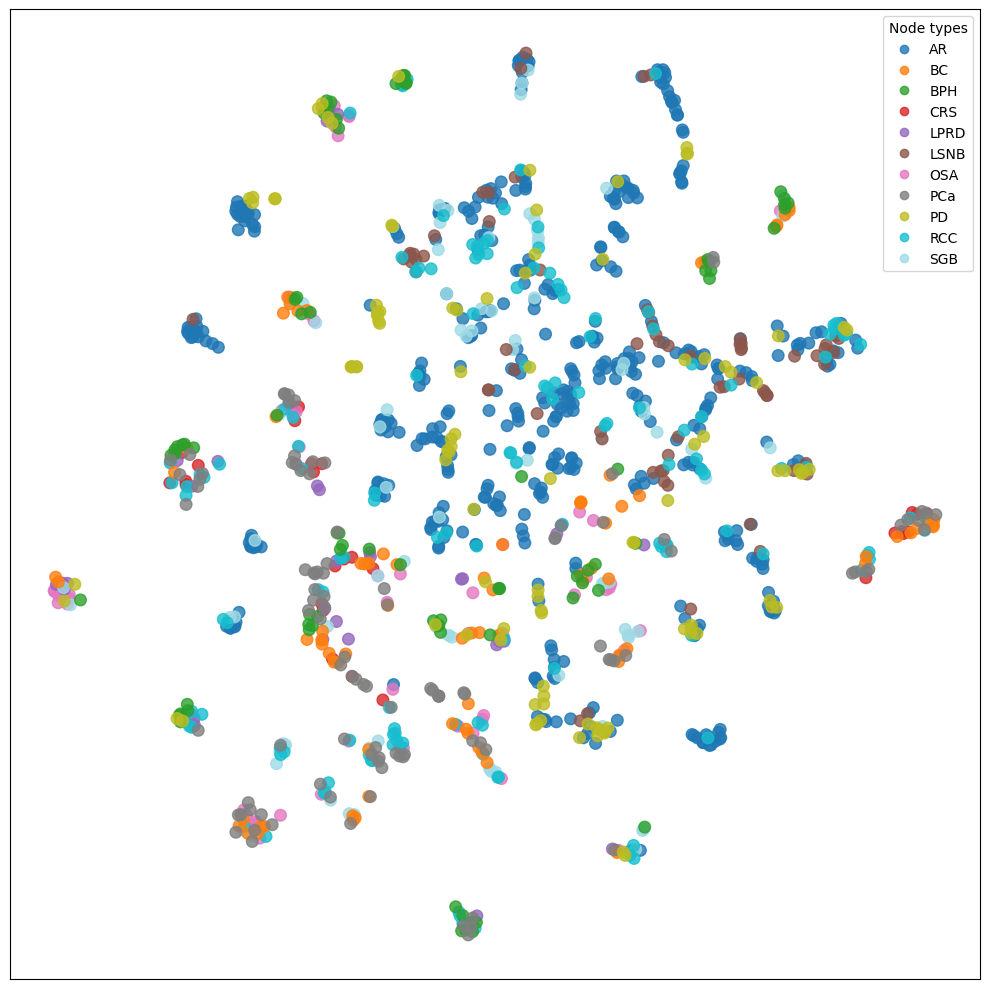

In [88]:
model.eval()
out, z = model(data.x, data.edge_index)

visualize(z, data.y, groups_id)

In [89]:
# Calculate accuracy
def accuracy(pred_y, y):
    return (pred_y == y).sum() / len(y)

In [90]:
# Train

criterion = torch.nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)#, weight_decay=5e-4)

# Data for animations
embeddings = []
losses = []
accuracies = []
outputs = []
epochs = 1000

# Training loop
pbar = tqdm(range(1, epochs + 1))
for epoch in pbar:
    # Mode train
    model.train()
    
    # Clear gradients
    optimizer.zero_grad()

    # Forward pass
    out, z = model(data.x, data.edge_index)

    # Calculate loss function
    loss = criterion(out, data.y)

    # Calculate accuracy
    acc = accuracy(out[data.train_mask].argmax(dim=1), data.y[data.train_mask])

    # Compute gradients
    loss.backward()

    # Tune parameters
    optimizer.step()

    # Store data for animations
    embeddings.append(z)
    losses.append(loss.item())
    accuracies.append(acc)
    outputs.append(out.argmax(dim=1))

    # Print metrics
    pbar.set_description(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%")

    # Print metrics every 10 epochs
    """ if epoch % 10 == 0:
        print(f"Epoch {epoch:>3} | Loss: {loss:.2f} | Acc: {acc*100:.2f}%") """

Epoch   2 | Loss: 2.42 | Acc: 2.61%:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 1000 | Loss: 0.28 | Acc: 89.08%: 100%|██████████| 1000/1000 [00:33<00:00, 29.46it/s]


In [91]:
# Model evaluation
model.eval()
out, z = model(data.x, data.edge_index)
acc = accuracy(out[data.test_mask].argmax(dim=1), data.y[data.test_mask])
print(f"Acc: {acc*100:.2f}%")

Acc: 91.60%


In [92]:
# Get node embeddings
print(z.shape)
z

torch.Size([1248, 128])


tensor([[0.0948, 0.0000, 4.3117,  ..., 0.0000, 4.3834, 1.2203],
        [0.1514, 0.0000, 3.8309,  ..., 0.2783, 3.1468, 1.0982],
        [0.0000, 0.0000, 2.4645,  ..., 0.0000, 2.4030, 1.7877],
        ...,
        [1.8708, 0.0000, 4.9039,  ..., 2.7086, 0.3495, 0.0000],
        [1.5792, 0.0000, 5.9190,  ..., 1.9872, 1.0059, 0.0000],
        [1.4314, 0.0000, 4.3434,  ..., 1.8572, 0.8905, 0.0431]],
       grad_fn=<ReluBackward0>)

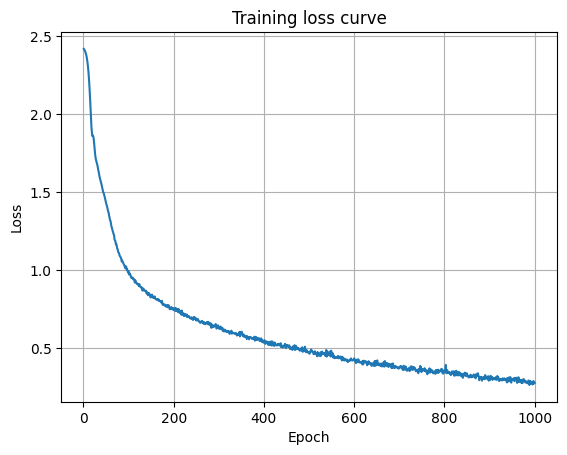

In [93]:
# Plot loss curve
plt.figure()
plt.plot(range(1, epochs + 1), losses, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training loss curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

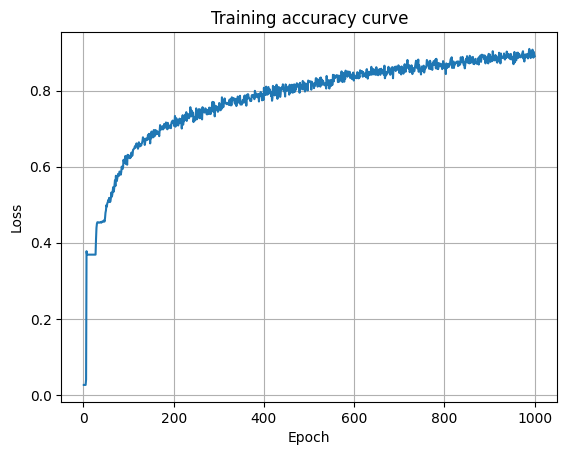

In [94]:
# Plot accuracy curve
plt.figure()
plt.plot(range(1, epochs + 1), accuracies, marker="")

# Axis labels
plt.xlabel("Epoch")
plt.ylabel("Loss")

# Title
plt.title("Training accuracy curve")

# Grid for better visualization
plt.grid(True)

# Display plot
plt.show()

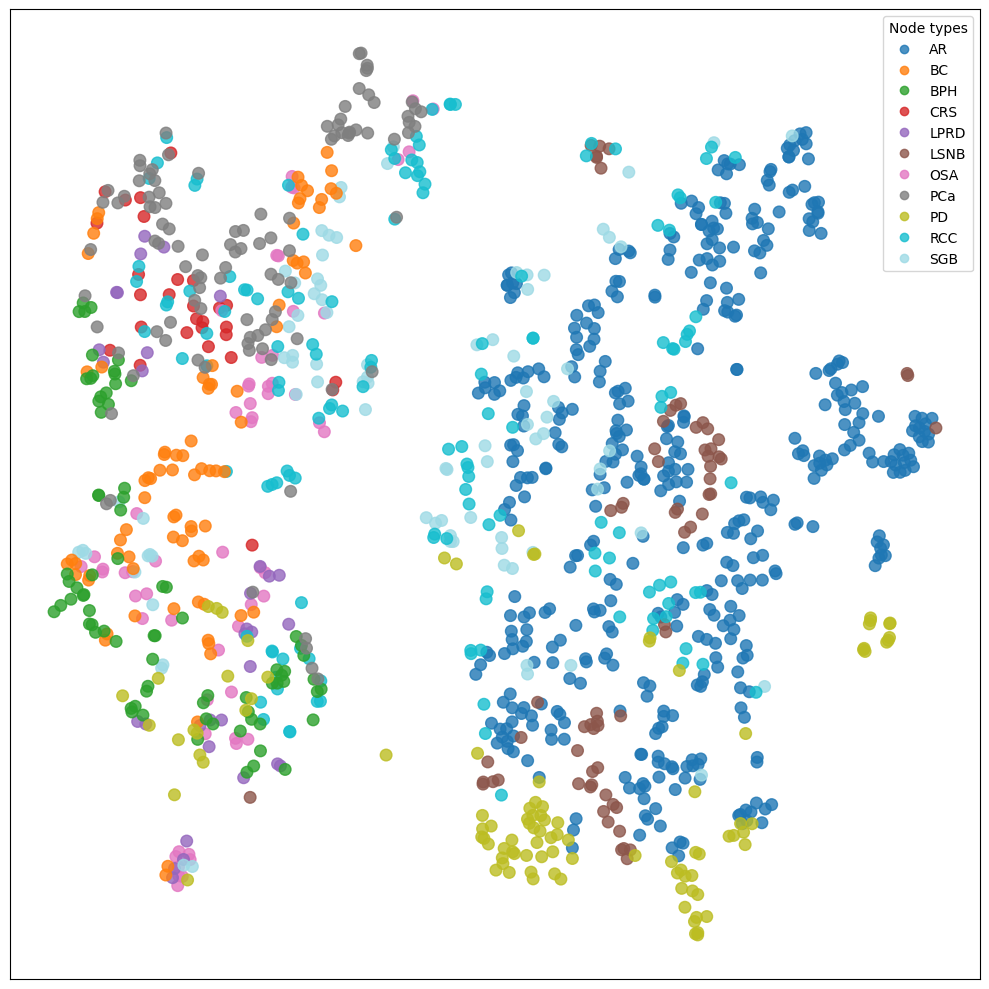

In [95]:
visualize(z, data.y, groups_id)

In [65]:
%%capture

plt.rcParams["animation.bitrate"] = 3000

def animate(i):
    embed = embeddings[i].detach().cpu().numpy()
    ax.clear()
    ax.scatter(embed[:, 0], embed[:, 1], embed[:, 2], s=200, c=data.y, cmap="gist_rainbow", vmin=-2, vmax=3)
    plt.title(f'Epoch: {i + 1} | Loss: {losses[i]:.4f}', fontsize=18, pad=40)

fig = plt.figure(figsize=(10, 10))
plt.axis("off")
ax = fig.add_subplot(projection="3d")
plt.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

anim = animation.FuncAnimation(fig, animate, np.arange(1, epochs, 1), interval=100, repeat=False)
html = HTML(anim.to_html5_video())

CalledProcessError: Command '['ffmpeg', '-f', 'rawvideo', '-vcodec', 'rawvideo', '-s', '1000x1000', '-pix_fmt', 'rgba', '-framerate', '10.0', '-loglevel', 'error', '-i', 'pipe:', '-vcodec', 'h264', '-pix_fmt', 'yuv420p', '-b', '3000k', '-y', '/tmp/tmp5eqw9c2_/temp.m4v']' returned non-zero exit status 1.

----

In [ ]:
# get groups name
groups_id_no = params["groups_id_no"]
groups_id = []
for item in df_join_raw.iloc[:, 3:].columns.values:
    group_id = item.split("_")[0]
    if group_id not in groups_id and group_id not in groups_id_no:
        groups_id.append(group_id)
groups_id

['AR', 'CRS', 'OSA', 'LPRD', 'SGB', 'LSNB', 'RCC', 'BC', 'BPH', 'PCa', 'PD']

In [ ]:
# delete no sample columns
""" columns_delete = [columna for columna in df_join_raw.columns if columna.split("_")[0] in columns_no_sample]
df_join_raw.drop(columns_delete, axis=1, inplace=True)
df_join_raw """

' columns_delete = [columna for columna in df_join_raw.columns if columna.split("_")[0] in columns_no_sample]\ndf_join_raw.drop(columns_delete, axis=1, inplace=True)\ndf_join_raw '

In [ ]:
# get subgroups names

""" def get_subgroups_id(df_join_raw, groups, by_group=False):
    dict_groups_id = {}
    for group in groups:
        # get group
        if by_group:
            dict_groups_id[group] = ["1"]
        else:
            columns = list(df_join_raw.filter(like=group).columns)
            subgroups = [item.split("{}_".format(group))[1].split(".")[0] for item in columns]
            subgroups = np.unique(subgroups)
            dict_groups_id[group] = subgroups.tolist()
    return dict_groups_id """

subgroups_id = get_subgroups_id(df_join_raw, groups_id)
subgroups_id

{'AR': ['1', '2'],
 'CRS': ['1', '2'],
 'OSA': ['1', '2'],
 'LPRD': ['1', '2'],
 'SGB': ['1', '2'],
 'LSNB': ['1', '2'],
 'RCC': ['1', '2'],
 'BC': ['1', '2'],
 'BPH': ['1', '2'],
 'PCa': ['1', '2'],
 'PD': ['1', '2']}

In [ ]:
# count analtical repetitions
# df_join_raw.filter(like="AA_1.")

In [ ]:
# check distribution

In [ ]:
""" x = df_join_raw.iloc[2, 3:]
print(x.min(), x.max(), x.mean())
x.hist(bins=200) """

' x = df_join_raw.iloc[2, 3:]\nprint(x.min(), x.max(), x.mean())\nx.hist(bins=200) '

In [ ]:
# f_join_raw.iloc[:, 5].hist(bins=100)

In [ ]:
params["controls"], groups_id

(['AR'],
 ['AR', 'CRS', 'OSA', 'LPRD', 'SGB', 'LSNB', 'RCC', 'BC', 'BPH', 'PCa', 'PD'])

In [ ]:
# get groups combination
groups = []
controls = params["controls"]

groups = []
for control in controls:
    for group_id in groups_id:
        if control != group_id:
            groups.append([control, group_id])
print(groups)

[['AR', 'CRS'], ['AR', 'OSA'], ['AR', 'LPRD'], ['AR', 'SGB'], ['AR', 'LSNB'], ['AR', 'RCC'], ['AR', 'BC'], ['AR', 'BPH'], ['AR', 'PCa'], ['AR', 'PD']]


### Create folders

In [ ]:
# create experiments folder
try: 
    os.mkdir("experiments/output/{}".format(exp))
    os.mkdir("experiments/output/{}/correlations".format(exp))
    os.mkdir("experiments/output/{}/preprocessing".format(exp))
    os.mkdir("experiments/output/{}/preprocessing/edges".format(exp))
    os.mkdir("experiments/output/{}/preprocessing/graphs_data".format(exp))
    os.mkdir("experiments/output/{}/loss".format(exp))
    os.mkdir("experiments/output/{}/node_embeddings".format(exp))
    os.mkdir("experiments/output/{}/common_nodes".format(exp))
    os.mkdir("experiments/output/{}/filter_raw".format(exp))
    os.mkdir("experiments/output/{}/plots".format(exp))
except OSError as error: 
    print(error)

### Save dataset and parameters

In [ ]:
# save dataset
df_join_raw.to_csv("experiments/input/{}_raw.csv".format(exp), index=True)

# save parameters
parameters = {
    "exp": exp,
    "methods": params["methods"],
    "data_variations": params["data_variations"],
    "has_transformation": params["has_transformation"],
    "controls": params["controls"],
    "dimension": params["dimension"],
    "threshold_corr": params["threshold_corr"],
    "threshold_log2": params["threshold_log2"],
    "alpha": params["alpha"],
    "iterations": params["iterations"],
    "raw_data_file": params["raw_data_file"],
    "groups_id": groups_id,
    "subgroups_id": subgroups_id,
    "groups": groups,
    "groups_id_no": params["groups_id_no"],
    "sensitivity": params["sensitivity"],
    
    "from": params["from"],
    "cuda": params["cuda"],
    "epochs": params["epochs"],
    "lr": params["lr"],
    "weight_decay": params["weight_decay"],
    "patience": params["patience"],
    "contamination": params["contamination"],
    "n_jobs": params["n_jobs"],

    "seeds": params["seeds"],
    "obs": params["obs"]
}

with open("experiments/output/{}/parameters.json".format(exp), "w") as outfile:
    json.dump(parameters, outfile, indent=4)

In [ ]:
experiments = {
    "exp": exp
}

with open("exp.json".format(experiments), "w") as outfile:
    json.dump(experiments, outfile, indent=4)

In [ ]:
# return exp